# 실습 2-2 : 로지스틱 회귀

#### **<실습 내용>**

1. 실습 데이터 탐색 및 전처리
- 구조적 정보 / 통계적 정보
- 범주형 변수 처리 (One-Hot Encoding)
- 입출력 변수 분할
- 학습/테스트 데이터 분할
- 스케일링

2. 로지스틱 회귀
- 모델 학습 및 성능 평가
- 회귀 계수 해석

## 분석 준비

### 주요 라이브러리 호출

In [30]:
import pandas as pd
import numpy as np 

# 데이터 탐색을 위한 주요 시각화 라이브러리 호출 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 그래프에 한글이 깨지거나(경고: Glyph ... missing from font(s) DejaVu Sans) 안 보이는 문제 방지
# Windows 기본 한글 폰트인 '맑은 고딕(Malgun Gothic)'으로 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False   # 한글 폰트 사용 시 마이너스(-) 기호가 깨지는 문제 방지

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

### 데이터 불러오기

In [2]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day2-2_data.csv"))

---

## 1) 데이터 탐색 및 전처리

### 1-1) 구조적 정보

In [3]:
# 앞부분 데이터 확인
MF_Data.head(n=5)

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
0,67,82,Operator1,291,1,1,1041,846,334,706,1086,256,1295,766,968,1185,1355,1842,90,No
1,68,77,Operator1,1180,1,1,1915,1194,637,1093,524,919,245,403,723,1446,719,748,91,No
2,64,76,Operator1,1406,1,1,511,1577,1121,1948,1882,1301,273,1927,1123,717,1518,1689,92,No
3,63,80,Operator1,550,1,1,1754,1834,1413,1151,945,1312,1494,1755,1434,502,1336,711,93,No
4,65,81,Operator1,1928,1,2,1326,1082,233,1441,1736,1033,1549,802,1819,1616,1507,507,94,No


In [4]:
# 데이터 정보 확인
MF_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7900 entries, 0 to 7899
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Temperature                   7900 non-null   int64 
 1   Humidity                      7900 non-null   int64 
 2   Operator                      7900 non-null   object
 3   Measure1                      7900 non-null   int64 
 4   Measure2                      7900 non-null   int64 
 5   Measure3                      7900 non-null   int64 
 6   Measure4                      7900 non-null   int64 
 7   Measure5                      7900 non-null   int64 
 8   Measure6                      7900 non-null   int64 
 9   Measure7                      7900 non-null   int64 
 10  Measure8                      7900 non-null   int64 
 11  Measure9                      7900 non-null   int64 
 12  Measure10                     7900 non-null   int64 
 13  Measure11         

In [5]:
# 데이터 크기 확인
print("데이터 크기 :", MF_Data.shape)

데이터 크기 : (7900, 20)


- 현재 설비 상태(온도, 습도, 센서값, 이전 고장 후 경과시간)를 이용하여 향후 고장(Failure) 발생 여부를 예측하는 이진 분류 데이터셋

### 1-2) 통계적 정보

In [6]:
# 요약 통계량 확인
MF_Data.describe(include="all")

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
count,7900.000000,7900.000000,7900,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900.000000,7900
unique,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Operator2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,NaN,1751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7825
mean,64.055949,83.703671,NaN,1093.450380,1.488608,1.002025,1068.763924,1075.140000,1077.938228,1089.496076,1075.945190,1082.146962,1081.997975,1088.974684,1088.998228,1074.699241,1091.435949,1083.851899,210.289241,NaN
std,2.668864,4.806356,NaN,535.438555,1.114985,0.813854,535.724483,533.727253,533.450621,537.130674,537.184388,531.296016,538.075952,534.544434,532.217592,535.322092,536.685002,537.114706,143.875473,NaN
min,60.000000,65.000000,NaN,155.000000,0.000000,0.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,1.000000,NaN
25%,62.000000,80.000000,NaN,633.000000,0.000000,0.000000,605.000000,603.750000,626.000000,625.000000,609.000000,634.000000,618.000000,628.000000,630.000000,605.000000,622.000000,615.750000,89.000000,NaN
50%,64.000000,84.000000,NaN,1098.500000,2.000000,1.000000,1056.000000,1075.000000,1073.000000,1091.000000,1073.000000,1076.000000,1076.500000,1093.000000,1081.000000,1064.500000,1090.500000,1078.000000,192.000000,NaN
75%,66.000000,87.000000,NaN,1556.000000,2.000000,2.000000,1530.000000,1541.250000,1541.250000,1561.000000,1540.000000,1527.250000,1547.000000,1548.000000,1549.500000,1537.000000,1564.250000,1552.000000,314.000000,NaN


### 1-3) 시각적 탐색

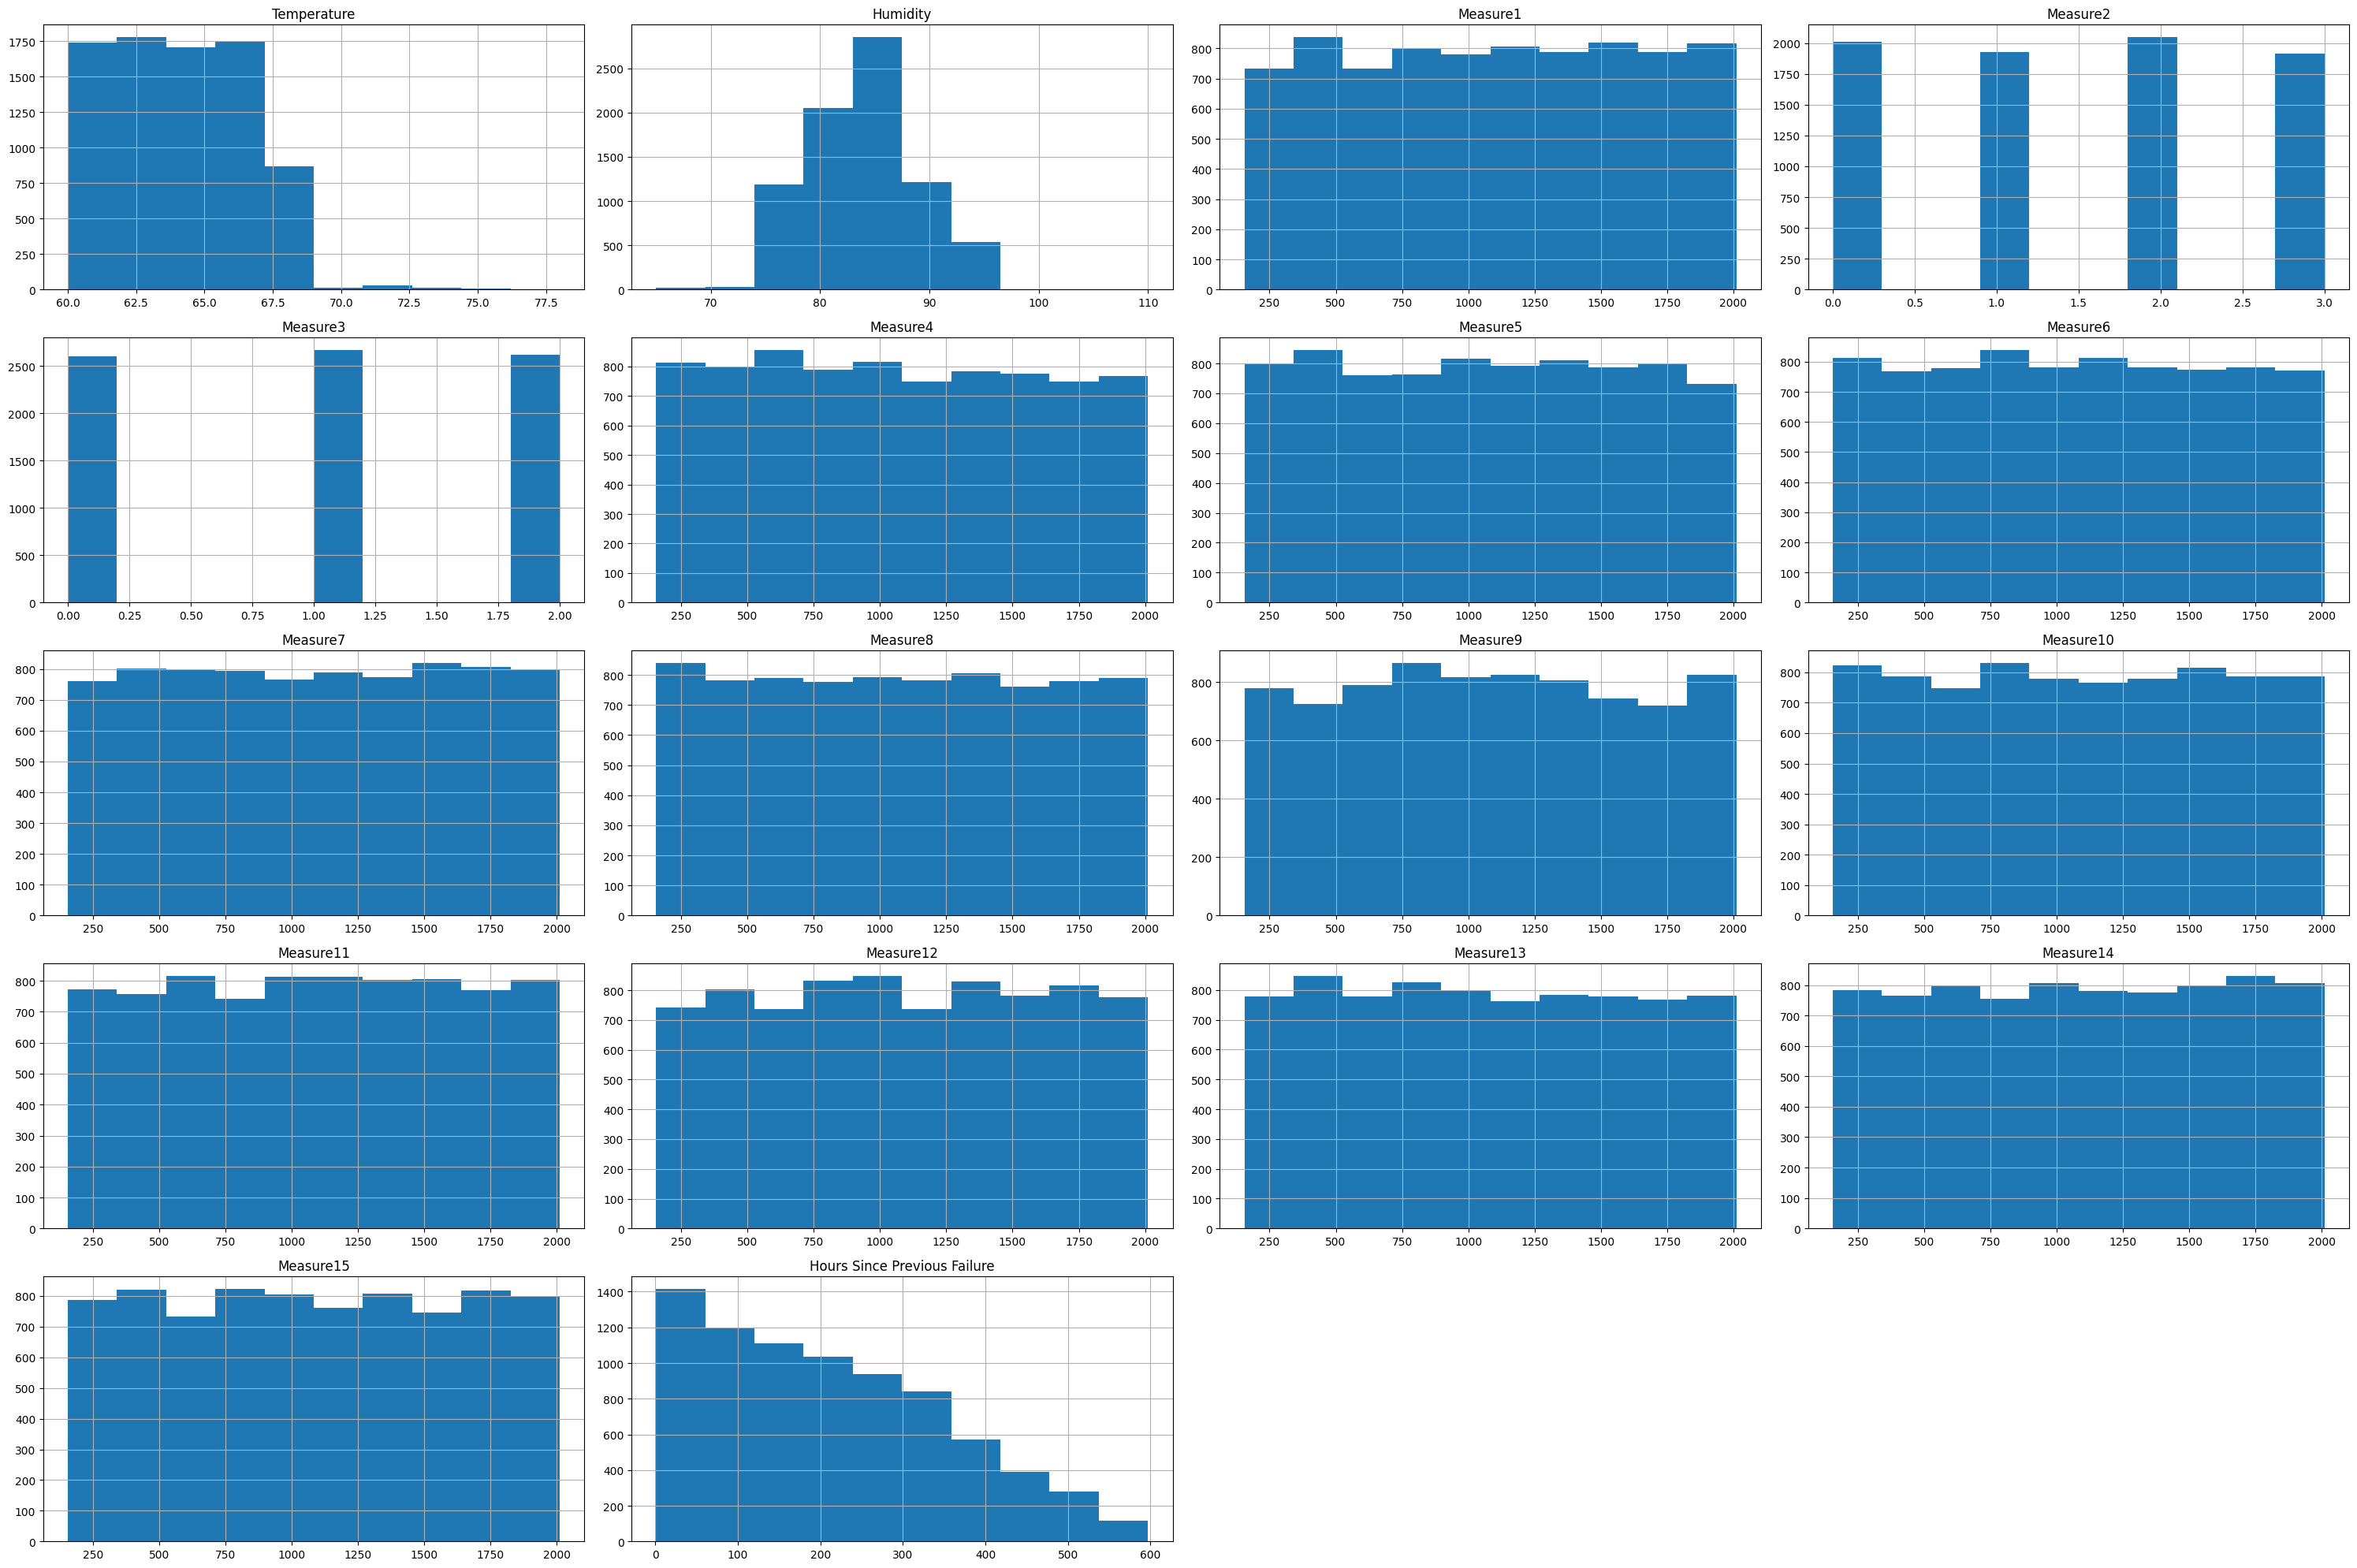

In [7]:
# 히스토그램
MF_Data.hist(figsize=(30, 20))
plt.tight_layout()
plt.show()

> Measure2와 Measure3은 값이 소수의 정수값만 가지므로 **범주형 변수**로 처리해야 함

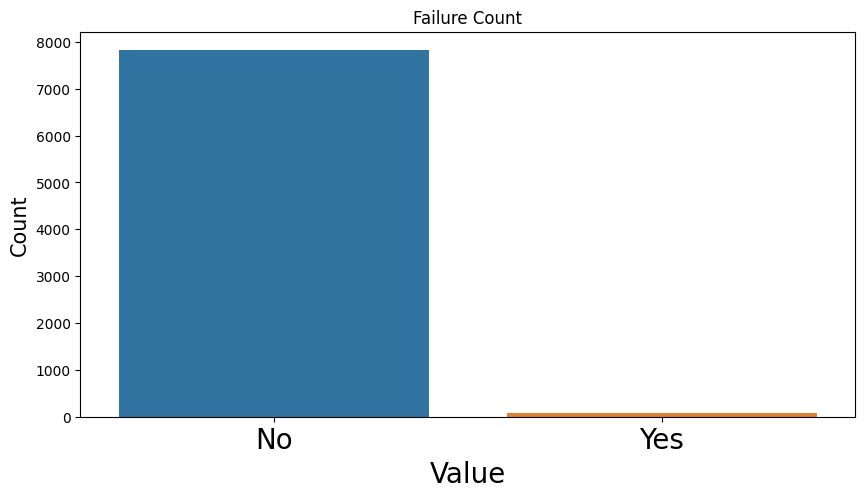

In [8]:
plt.figure(figsize=(10,5))
plt.title("Failure Count")

counts = MF_Data["Failure"].value_counts()

sns.barplot(x=counts.index,
            y=counts.values,
            hue=counts.index)

plt.xticks(fontsize=20)
plt.xlabel("Value",fontsize=20)
plt.ylabel("Count",fontsize=15)
plt.show()

### 1-4) 입출력 변수 분할

In [9]:
Y = MF_Data["Failure"]
X = MF_Data.drop(["Failure"], axis=1)

### 1-5) 범주형 변수 처리 (One-Hot Encoding)

> **One-Hot Encoding**은 범주형 변수의 각 항목을 0과 1로 표현하는 방법임
> - 범주가 k개인 변수를 k개의 새로운 이진 변수로 변환함
> - `pd.get_dummies()`를 사용하면 범주형 변수를 자동으로 One-Hot Encoding 할 수 있음

In [10]:
# Measure2, Measure3을 범주형으로 변환
print("Measure2 고유값:", X["Measure2"].unique())
print("Measure3 고유값:", X["Measure3"].unique())

X["Measure2"] = X["Measure2"].astype("category")
X["Measure3"] = X["Measure3"].astype("category")

Measure2 고유값: [1 0 2 3]
Measure3 고유값: [1 2 0]


In [11]:
# One-Hot Encoding 적용
X = pd.get_dummies(X)
data_columns = X.columns

X.head()

,Temperature,Humidity,Measure1,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,...,Operator_Operator6,Operator_Operator7,Operator_Operator8,Measure2_0,Measure2_1,Measure2_2,Measure2_3,Measure3_0,Measure3_1,Measure3_2
0,67,82,291,1041,846,334,706,1086,256,1295,...,False,False,False,False,True,False,False,False,True,False
1,68,77,1180,1915,1194,637,1093,524,919,245,...,False,False,False,False,True,False,False,False,True,False
2,64,76,1406,511,1577,1121,1948,1882,1301,273,...,False,False,False,False,True,False,False,False,True,False
3,63,80,550,1754,1834,1413,1151,945,1312,1494,...,False,False,False,False,True,False,False,False,True,False
4,65,81,1928,1326,1082,233,1441,1736,1033,1549,...,False,False,False,False,True,False,False,False,False,True


### 1-6) 출력변수 확인

> 불량(Yes) 비율이 약 0.9%로 **매우 불균형한 데이터**임

In [12]:
# 클래스 비율 확인
print(Y.value_counts())
print()
print(Y.value_counts(normalize=True))

Failure
No     7825
Yes      75
Name: count, dtype: int64

Failure
No     0.990506
Yes    0.009494
Name: proportion, dtype: float64


In [13]:
# 출력변수 값 변경 (No -> 0, Yes -> 1)
Y = Y.replace({"No": 0, "Yes": 1}).infer_objects(copy=False)
Y.value_counts()

C:\Users\Admin\AppData\Local\Temp\ipykernel_26116\2680182726.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = Y.replace({"No": 0, "Yes": 1}).infer_objects(copy=False)


Failure
0    7825
1      75
Name: count, dtype: int64

### 1-7) 학습/테스트 데이터 분할

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)

print("전체 데이터 크기   :", X.shape)
print("학습 데이터 크기   :", X_train.shape)
print("테스트 데이터 크기 :", X_test.shape)

전체 데이터 크기   : (7900, 31)
학습 데이터 크기   : (5530, 31)
테스트 데이터 크기 : (2370, 31)


In [15]:
# 클래스 비율이 유지되는지 확인
print("Y 클래스 비율")
print(np.round(Y.value_counts(normalize=True), 3))
print()
print("Y_train 클래스 비율")
print(np.round(Y_train.value_counts(normalize=True), 3))
print()
print("Y_test 클래스 비율")
print(np.round(Y_test.value_counts(normalize=True), 3))

Y 클래스 비율
Failure
0    0.991
1    0.009
Name: proportion, dtype: float64

Y_train 클래스 비율
Failure
0    0.99
1    0.01
Name: proportion, dtype: float64

Y_test 클래스 비율
Failure
0    0.991
1    0.009
Name: proportion, dtype: float64


### 1-8) 스케일링

> 로지스틱 회귀는 입력변수의 **스케일에 민감**하므로, MinMax 또는 Standard 스케일링을 적용해야함

In [16]:
mc = MinMaxScaler()
X_train = mc.fit_transform(X_train)
X_test = mc.transform(X_test)

---

## 2) 로지스틱 회귀

> **로지스틱 회귀**는 출력변수가 범주형(정상/불량)인 경우에 사용되는 분류 모델임
> - 특정 사건이 발생할 **확률**을 예측하며, 확률이 기준값(보통 0.5) 이상이면 해당 클래스로 분류함
> - 로지스틱 함수: $p(X) = \frac{e^{\hat{\beta}_0 + \hat{\beta}_1 X_1 + \cdots + \hat{\beta}_k X_k}}{1 + e^{\hat{\beta}_0 + \hat{\beta}_1 X_1 + \cdots + \hat{\beta}_k X_k}}$
> - 회귀 계수 $\hat{\beta}_k$가 양수면 $X_k$가 증가할수록 불량 확률이 높아지고, 음수면 낮아짐

In [17]:
# 분류 모형 성능 지표 산출 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % (accuracy_score(real, pred)))
    print("Precision : %.3f" % (precision_score(real, pred)))
    print("Recall    : %.3f" % (recall_score(real, pred)))
    print("F1-score  : %.3f" % (f1_score(real, pred)))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

### 2-1) 모델 학습

In [18]:
LR_model = LogisticRegression()
LR_model.fit(np.array(X_train), np.array(Y_train))

LogisticRegression()

### 2-2) 회귀 계수 확인

> 로지스틱 회귀에서 회귀 계수의 절대값이 클수록 해당 변수의 **분류 영향력이 큼**.

In [19]:
coef_data = pd.DataFrame({"Variable": data_columns, "Coef": np.abs(LR_model.coef_[0])})
coef_data.sort_values(by="Coef", ascending=False)

,Variable,Coef
0,Temperature,6.475519
1,Humidity,5.671526
15,Hours Since Previous Failure,1.891511
23,Operator_Operator8,0.814493
10,Measure11,0.699583
9,Measure10,0.626409
7,Measure8,0.538488
2,Measure1,0.537912
8,Measure9,0.390579
25,Measure2_1,0.349988


### 2-3) 성능 평가

> 분류 모델의 주요 성능 지표:
> - **Accuracy (정확도)**: 전체 중 올바르게 분류한 비율
> - **Precision (정밀도)**: 불량으로 예측한 것 중 실제 불량의 비율
> - **Recall (재현율)**: 실제 불량 중 불량으로 예측한 비율
> - **F1-score**: Precision과 Recall의 조화 평균

In [20]:
LR_predict = LR_model.predict(X_test)
get_classscore(Y_test, LR_predict)

Accuracy  : 0.992
Precision : 1.000
Recall    : 0.136
F1-score  : 0.240

혼동행렬
[[2348    0]
 [  19    3]]


### 2-4) 확률 예측

> `predict_proba()`를 사용하면 각 클래스에 속할 **확률값**을 확인할 수 있음

In [21]:
# 테스트 데이터에 대한 사건 발생 확률 예측
LR_predict_proba = LR_model.predict_proba(X_test)
LR_predict_proba[:5]

array([[0.98980409, 0.01019591],
       [0.98435763, 0.01564237],
       [0.99840493, 0.00159507],
       [0.99861951, 0.00138049],
       [0.99230269, 0.00769731]])

In [22]:
LR_predict_proba

array([[9.89804088e-01, 1.01959124e-02],
       [9.84357627e-01, 1.56423726e-02],
       [9.98404929e-01, 1.59507131e-03],
       ...,
       [9.98721791e-01, 1.27820944e-03],
       [9.97855042e-01, 2.14495762e-03],
       [9.99143802e-01, 8.56198467e-04]])

---

## 3) Vibe Coding 실습

### 3-1) 전처리 심화

**[과제 1]** 지수는 불량(Failure) 비율이 약 0.9%에 불과하다는 점을 확인했습니다. 이처럼 클래스 불균형이 심한 데이터에서는 전처리, 로지스틱 회귀 모델 학습, 평가 방법, 고도화 등을 어떻게 설정해야 하는지가 중요합니다. AI와 함께 이를 해결할 수 있는 방법을 찾아보고, 실제로 적용하여 모델 성능이 얼마나 개선되는지 확인해 보세요.

### 3-2) 모델링 및 고도화 심화

**[과제 2]** 지수는 predict_proba로 얻은 불량 확률을 그냥 0.5 기준으로 나누는 게 이 데이터에 적합한지 의문이 듭니다. 임계값(threshold)을 바꿔가며 Precision과 Recall이 어떻게 trade-off 되는지 살펴보는 방법을 AI와 논의하고, 이 데이터에 더 적합한 임계값을 찾아 적용해 보세요.

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
# Failure(=1)일 확률만 추출
proba_failure = LR_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 1.0, 0.1)  # 0.1 ~ 0.9
rows = []
for t in thresholds:
    pred_t = (proba_failure >= t).astype(int)
    rows.append({
        "Threshold": round(t, 1),
        "Precision": precision_score(Y_test, pred_t, zero_division=0),
        "Recall":    recall_score(Y_test, pred_t, zero_division=0),
        "F1":        f1_score(Y_test, pred_t, zero_division=0),
        "예측_불량건수": int(pred_t.sum()),
    })
threshold_df = pd.DataFrame(rows)
threshold_df[["Precision", "Recall", "F1"]] = threshold_df[["Precision", "Recall", "F1"]].round(3)
threshold_df

,Threshold,Precision,Recall,F1,예측_불량건수
0,0.1,0.938,0.682,0.789,16
1,0.2,1.000,0.455,0.625,10
2,0.3,1.000,0.409,0.581,9
3,0.4,1.000,0.273,0.429,6
4,0.5,1.000,0.136,0.240,3
5,0.6,1.000,0.091,0.167,2
6,0.7,0.000,0.000,0.000,0
7,0.8,0.000,0.000,0.000,0
8,0.9,0.000,0.000,0.000,0


C:\Users\Admin\AppData\Local\Temp\ipykernel_26116\1908355246.py:12: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_26116\1908355246.py:12: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_26116\1908355246.py:12: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Admin\Miniconda3\envs\day4\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\Miniconda3\envs\day4\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\Miniconda3\envs\day4\lib\site-packages

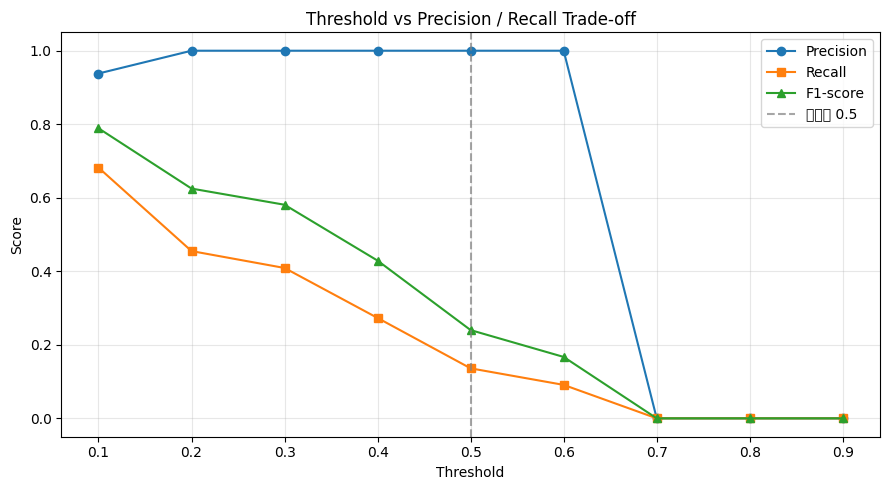

In [24]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"],    marker="s", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"],        marker="^", label="F1-score")
plt.axvline(x=0.5, color="gray", linestyle="--", alpha=0.7, label="기본값 0.5")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall Trade-off")
plt.xticks(thresholds)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
print("F1이 가장 높은 threshold:", best_row["Threshold"])
print(best_row)

best_t = best_row["Threshold"]
pred_default = (proba_failure >= 0.5).astype(int)
pred_best    = (proba_failure >= best_t).astype(int)
print(f"[기본 threshold=0.5] 혼동행렬")
print(confusion_matrix(Y_test, pred_default))
print(f"\n[선택 threshold={best_t}] 혼동행렬")
print(confusion_matrix(Y_test, pred_best))

F1이 가장 높은 threshold: 0.1
Threshold     0.100
Precision     0.938
Recall        0.682
F1            0.789
예측_불량건수      16.000
Name: 0, dtype: float64
[기본 threshold=0.5] 혼동행렬
[[2348    0]
 [  19    3]]

[선택 threshold=0.1] 혼동행렬
[[2347    1]
 [   7   15]]


**[과제 3]** 지수는 선형 회귀에서 Ridge·Lasso를 활용해 모델의 복잡도를 조절할 수 있다는 것을 배웠습니다. 이에 따라 로지스틱 회귀도 과적합을 방지하거나 모델의 복잡도를 조절할 수 있는 방법이 있는지 궁금해졌습니다. AI와 함께 모델 복잡도를 조절하는 기법을 찾아보고, 다양한 설정을 적용하여 성능과 회귀 계수의 변화를 비교해 보세요.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

feature_names = X.columns  # 스케일링 전 원-핫 인코딩된 변수명

# 비교할 규제 모델 정의 (C=1.0 동일 조건, 필요시 조정)
models = {
    "L2 (Ridge형)":      LogisticRegression(penalty="l2", C=1.0, solver="liblinear", max_iter=1000),
    "L1 (Lasso형)":      LogisticRegression(penalty="l1", C=1.0, solver="liblinear", max_iter=1000),
    "ElasticNet":        LogisticRegression(penalty="elasticnet", C=1.0, l1_ratio=0.5,
                                            solver="saga", max_iter=5000),
    "규제강함 L2 (C=0.01)": LogisticRegression(penalty="l2", C=0.01, solver="liblinear", max_iter=1000),
    "규제강함 L1 (C=0.01)": LogisticRegression(penalty="l1", C=0.01, solver="liblinear", max_iter=1000),
}

score_rows = []
coef_dict = {}

for name, model in models.items():
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)

    score_rows.append({
        "Model":     name,
        "Accuracy":  accuracy_score(Y_test, pred),
        "Precision": precision_score(Y_test, pred, zero_division=0),
        "Recall":    recall_score(Y_test, pred, zero_division=0),
        "F1":        f1_score(Y_test, pred, zero_division=0),
    })
    coef_dict[name] = model.coef_[0]

score_df = pd.DataFrame(score_rows)
score_df.iloc[:, 1:] = score_df.iloc[:, 1:].round(3)
score_df

,Model,Accuracy,Precision,Recall,F1
0,L2 (Ridge형),0.992,1.0,0.136,0.240
1,L1 (Lasso형),0.996,1.0,0.591,0.743
2,ElasticNet,0.994,1.0,0.318,0.483
3,규제강함 L2 (C=0.01),0.991,0.0,0.000,0.000
4,규제강함 L1 (C=0.01),0.991,0.0,0.000,0.000


In [27]:
coef_df = pd.DataFrame(coef_dict, index=feature_names).round(3)
coef_df

,L2 (Ridge형),L1 (Lasso형),ElasticNet,규제강함 L2 (C=0.01),규제강함 L1 (C=0.01)
Temperature,6.218,9.890,7.978,0.003,0.0
Humidity,-5.859,-15.246,-7.103,-0.419,0.0
Measure1,-0.608,0.000,-0.313,-0.369,0.0
Measure4,-0.270,0.000,0.000,-0.349,0.0
Measure5,0.076,0.000,0.241,-0.326,0.0
Measure6,-0.026,0.000,0.057,-0.329,0.0
Measure7,0.003,0.000,0.037,-0.335,0.0
Measure8,-0.593,0.000,-0.278,-0.374,0.0
Measure9,-0.492,-0.369,-0.231,-0.360,0.0
Measure10,0.430,0.411,0.607,-0.314,0.0


In [28]:
for name in ["L1 (Lasso형)", "ElasticNet", "규제강함 L1 (C=0.01)"]:
    zeroed = coef_df.index[coef_df[name] == 0].tolist()
    print(f"[{name}] 계수가 0이 된 변수 수: {len(zeroed)}")
    print("  ->", zeroed)
    print()

[L1 (Lasso형)] 계수가 0이 된 변수 수: 19
  -> ['Measure1', 'Measure4', 'Measure5', 'Measure6', 'Measure7', 'Measure8', 'Measure12', 'Measure13', 'Measure15', 'Operator_Operator1', 'Operator_Operator4', 'Operator_Operator5', 'Operator_Operator6', 'Operator_Operator7', 'Measure2_1', 'Measure2_2', 'Measure2_3', 'Measure3_0', 'Measure3_2']

[ElasticNet] 계수가 0이 된 변수 수: 3
  -> ['Measure4', 'Operator_Operator2', 'Measure3_2']

[규제강함 L1 (C=0.01)] 계수가 0이 된 변수 수: 31
  -> ['Temperature', 'Humidity', 'Measure1', 'Measure4', 'Measure5', 'Measure6', 'Measure7', 'Measure8', 'Measure9', 'Measure10', 'Measure11', 'Measure12', 'Measure13', 'Measure14', 'Measure15', 'Hours Since Previous Failure', 'Operator_Operator1', 'Operator_Operator2', 'Operator_Operator3', 'Operator_Operator4', 'Operator_Operator5', 'Operator_Operator6', 'Operator_Operator7', 'Operator_Operator8', 'Measure2_0', 'Measure2_1', 'Measure2_2', 'Measure2_3', 'Measure3_0', 'Measure3_1', 'Measure3_2']



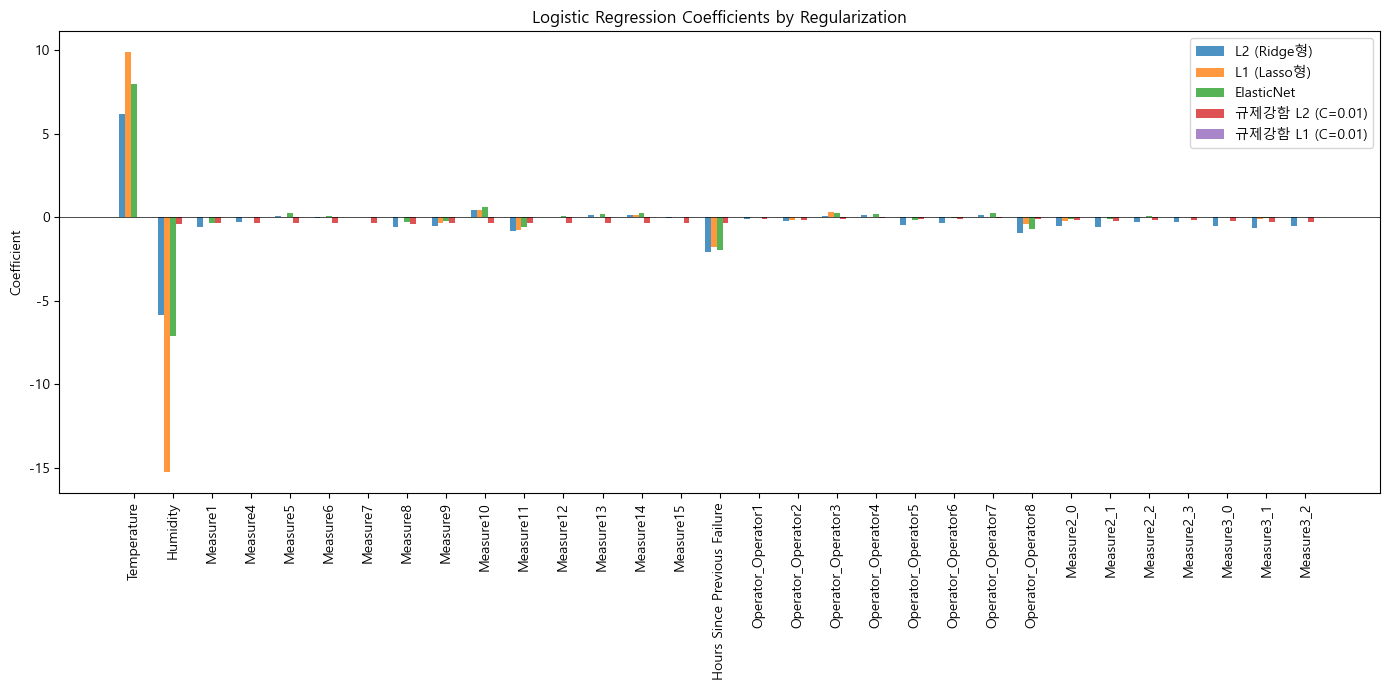

In [31]:
plt.figure(figsize=(14, 7))
x_pos = np.arange(len(feature_names))
width = 0.15
plot_models = ["L2 (Ridge형)", "L1 (Lasso형)", "ElasticNet",
               "규제강함 L2 (C=0.01)", "규제강함 L1 (C=0.01)"]

for i, name in enumerate(plot_models):
    plt.bar(x_pos + (i - 2) * width, coef_df[name], width, label=name, alpha=0.8)

plt.xticks(x_pos, feature_names, rotation=90)
plt.ylabel("Coefficient")
plt.title("Logistic Regression Coefficients by Regularization")
plt.axhline(y=0, color="black", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**[과제 4]** 지수는 모델이 구체적으로 어떤 케이스에서 틀리는지 직접 눈으로 확인하고 싶습니다. 모델이 잘못 예측한 데이터를 추려내는 방법을 AI와 상의해서 추출하고, 이 데이터들이 다른 데이터와 어떤 특징 차이를 보이는지 살펴보세요.

In [33]:
# [과제 4] 잘못 예측한 데이터 추려내기
# 가장 성능이 좋았던 L1(Lasso형, C=1.0) 모델 기준으로 분석

best_model = models["L1 (Lasso형)"]              # 앞 셀에서 이미 학습됨
pred = best_model.predict(X_test)                # 0/1 예측
proba = best_model.predict_proba(X_test)[:, 1]   # 불량(=1)일 확률

# Y_test는 원본 index를 그대로 보존하므로 스케일링 전 원본값으로 되돌릴 수 있음
result = MF_Data.loc[Y_test.index].copy()        # 해석용 원본 데이터
result["actual"] = Y_test.values
result["predicted"] = pred
result["proba_failure"] = proba.round(3)

# 오분류 유형 구분
def error_type(row):
    if row["actual"] == row["predicted"]:
        return "정답"
    elif row["actual"] == 1 and row["predicted"] == 0:
        return "FN(불량 놓침)"
    else:
        return "FP(정상 오탐)"

result["result_type"] = result.apply(error_type, axis=1)

print("예측 결과 분포:")
print(result["result_type"].value_counts())
print()

# 잘못 예측한 데이터만 추출
wrong = result[result["actual"] != result["predicted"]]
print(f"총 오분류 건수: {len(wrong)}  (FN={sum(wrong.result_type=='FN(불량 놓침)')}, FP={sum(wrong.result_type=='FP(정상 오탐)')})")
wrong

예측 결과 분포:
result_type
정답           2361
FN(불량 놓침)       9
Name: count, dtype: int64

총 오분류 건수: 9  (FN=9, FP=0)


,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,...,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure,actual,predicted,proba_failure,result_type
7413,65,86,Operator1,934,0,2,1279,976,1288,913,...,1333,314,649,544,1,Yes,1,0,0.001,FN(불량 놓침)
4222,62,81,Operator7,784,2,2,886,1645,1360,1008,...,522,1529,858,1973,449,Yes,1,0,0.000,FN(불량 놓침)
6745,69,75,Operator7,1859,0,2,1095,1349,1077,1597,...,241,1556,1809,439,1,Yes,1,0,0.245,FN(불량 놓침)
7412,64,77,Operator1,699,3,1,325,884,1092,1385,...,1281,785,1812,624,1,Yes,1,0,0.014,FN(불량 놓침)
1829,67,71,Operator2,993,3,2,538,994,1873,772,...,1839,929,1109,1652,1,Yes,1,0,0.344,FN(불량 놓침)
7410,66,89,Operator8,797,0,0,1514,449,1549,1151,...,1077,1483,309,1899,1,Yes,1,0,0.000,FN(불량 놓침)
3771,71,71,Operator2,733,1,1,239,1201,207,1216,...,1609,1441,182,1718,597,Yes,1,0,0.374,FN(불량 놓침)
1826,69,72,Operator2,1550,1,1,1292,167,1432,606,...,815,1873,666,1693,195,Yes,1,0,0.417,FN(불량 놓침)
148,63,85,Operator1,1774,0,1,1058,614,1448,985,...,787,1323,1865,1414,238,Yes,1,0,0.000,FN(불량 놓침)


In [34]:
# 오분류 데이터가 어떤 특징 차이를 보이는지 비교
# 수치형 변수 기준으로 (1) 전체 평균 (2) 정답 평균 (3) 오분류 평균 (4) FN 평균 비교

num_cols = MF_Data.select_dtypes(include="number").columns.tolist()

compare = pd.DataFrame({
    "전체_평균":   result[num_cols].mean(),
    "정답_평균":   result.loc[result.result_type == "정답", num_cols].mean(),
    "오분류_평균": wrong[num_cols].mean(),
    "FN_평균":     result.loc[result.result_type == "FN(불량 놓침)", num_cols].mean(),
}).round(2)

# 오분류가 전체 평균에서 얼마나 벗어났는지(차이) 컬럼 추가
compare["오분류-전체_차이"] = (compare["오분류_평균"] - compare["전체_평균"]).round(2)
compare.sort_values("오분류-전체_차이", key=abs, ascending=False)

,전체_평균,정답_평균,오분류_평균,FN_평균,오분류-전체_차이
Measure15,1077.32,1076.36,1328.44,1328.44,251.12
Measure10,1079.18,1078.30,1310.44,1310.44,231.26
Measure9,1082.12,1082.89,881.67,881.67,-200.45
Measure13,1063.66,1062.96,1248.11,1248.11,184.45
Measure6,1085.74,1085.08,1258.44,1258.44,172.70
Measure5,1075.72,1076.31,919.89,919.89,-155.83
Measure4,1063.77,1064.34,914.00,914.00,-149.77
Measure14,1094.39,1094.64,1028.78,1028.78,-65.61
Hours Since Previous Failure,209.78,209.95,164.89,164.89,-44.89
Measure12,1090.47,1090.60,1056.00,1056.00,-34.47


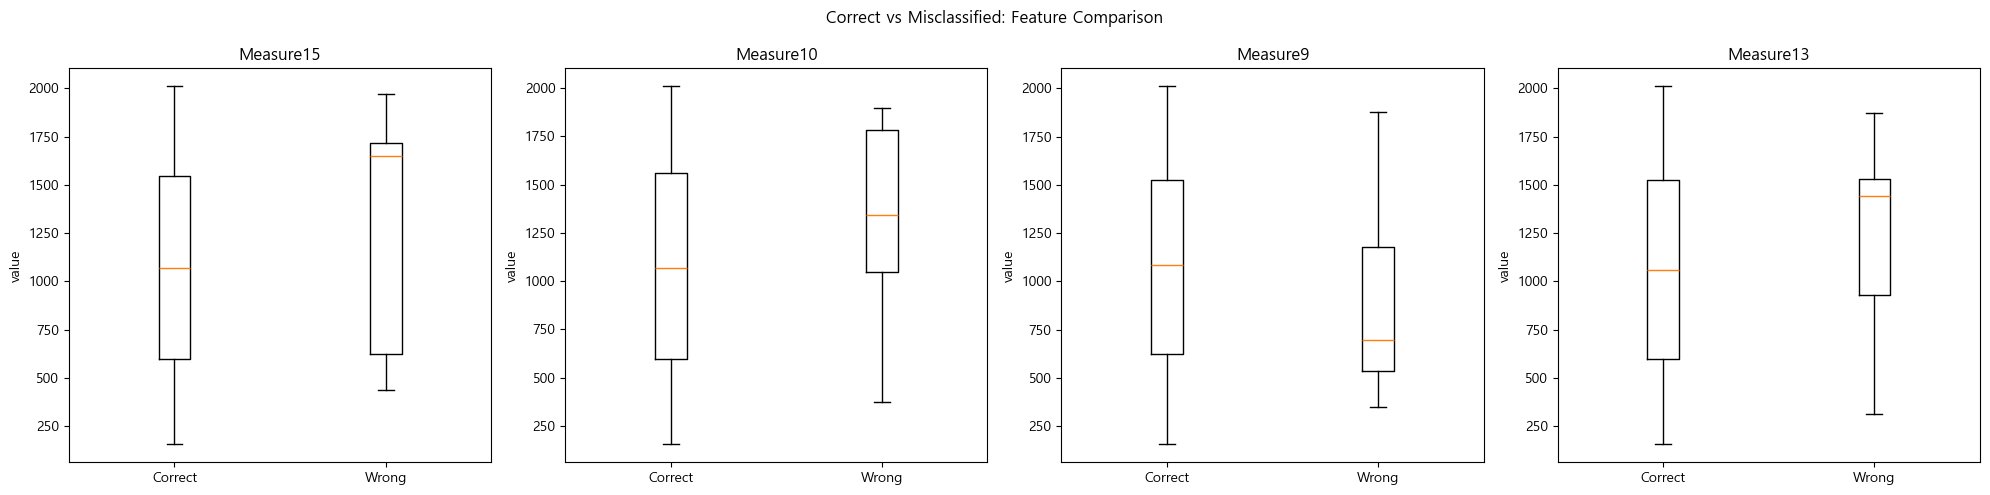

In [35]:
# 오분류(특히 FN)와 전체 데이터의 특징 차이가 큰 상위 변수 분포 비교
# 차이 절댓값이 큰 상위 4개 변수를 박스플롯으로 시각화

top_vars = compare["오분류-전체_차이"].abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, len(top_vars), figsize=(5 * len(top_vars), 5))
for ax, col in zip(axes, top_vars):
    data_correct = result.loc[result.result_type == "정답", col]
    data_wrong = wrong[col]
    ax.boxplot([data_correct, data_wrong], tick_labels=["Correct", "Wrong"])
    ax.set_title(col)
    ax.set_ylabel("value")

plt.suptitle("Correct vs Misclassified: Feature Comparison")
plt.tight_layout()
plt.show()